<a href="https://colab.research.google.com/github/juan0898/BackendEstudiantes/blob/main/Te_damos_la_bienvenida_a_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
files.upload()

Saving ventas_empresa_online.csv to ventas_empresa_online.csv


{'ventas_empresa_online.csv': b'\xef\xbb\xbfid_pedido,fecha,hora,id_cliente,segmento_cliente,ciudad,departamento,canal_venta,producto,categoria,cantidad,precio_unitario,descuento_pct,costo_envio,subtotal,total_pagado,metodo_pago,estado_pedido,dias_entrega,calificacion,devuelto\nORD-00001,2026-01-01,10:59,CLI-00694,Nuevo,Pereira,Risaralda,Marketplace,Crema facial,Cuidado personal,1,74000,20,0,74000,59200.0,Tarjeta cr\xc3\xa9dito,Enviado,,,No\nORD-00002,2026-05-13,13:32,CLI-00102,Recurrente,Bogot\xc3\xa1,Cundinamarca,Marketplace,Aud\xc3\xadfonos Bluetooth,Tecnolog\xc3\xada,2,89000,25,12000,178000,145500.0,Daviplata,Devuelto,3.0,2.0,S\xc3\xad\nORD-00003,2026-01-23,17:50,CLI-00385,Corporativo,Pereira,Risaralda,Instagram,Banda el\xc3\xa1stica fitness,Deportes,1,45000,20,8000,45000,44000.0,Nequi,Entregado,6.0,4.0,No\nORD-00004,2026-02-23,22:03,CLI-00754,VIP,Manizales,Caldas,Web,Webcam HD,Tecnolog\xc3\xada,1,120000,0,0,120000,120000.0,PSE,Entregado,3.0,4.0,No\nORD-00005,2026-04-06,18:24,CLI-0

In [4]:
df = pd.read_csv("ventas_empresa_online.csv")

In [12]:
df_clean["cantidad"] = df_clean["cantidad"].replace({
    "1 unidad": "1",
    "uno": "1",
    "dos": "2",
    "tres": "3",
    "10 uds": "10"
})

In [13]:
df_clean["cantidad"] = pd.to_numeric(
    df_clean["cantidad"],
    errors="coerce"
)

In [14]:
df_clean["cantidad"].value_counts(dropna=False)

,count
cantidad,
1.0,1430
2.0,270
3.0,95
4.0,33
NaN,7
0.0,2
-1.0,1
-5.0,1
50.0,1


In [15]:
precio_convertido = pd.to_numeric(
    df_clean["precio_unitario"],
    errors="coerce"
)

df_clean.loc[
    df_clean["precio_unitario"].notna() & precio_convertido.isna(),
    "precio_unitario"
].value_counts()

,count
precio_unitario,
cien mil,1
"$485,000",1
"69,000",1
32 000,1
abc,1
"185,000",1
"87,000",1
$76.000,1
$89.000,1


In [16]:
df_clean["precio_unitario"] = (
    df_clean["precio_unitario"]
    .astype("string")
    .str.strip()
    .str.replace("$", "", regex=False)
    .str.replace("COP", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(".", "", regex=False)
)

In [17]:
df_clean["precio_unitario"] = df_clean["precio_unitario"].replace({
    "cienmil": "100000"
})

In [18]:
df_clean["precio_unitario"] = pd.to_numeric(
    df_clean["precio_unitario"],
    errors="coerce"
)

In [19]:
df_clean["precio_unitario"].value_counts(dropna=False)

,count
precio_unitario,
74000,53
89000,48
155000,47
62000,46
76000,45
...,...
1450000,1
1,1
5000000,1


In [20]:
df_clean["descuento_pct"].value_counts(dropna=False)

,count
descuento_pct,
0,1075
5,190
10,183
20,137
15,122
25,109
NaN,14
0%,1
-5,1


In [21]:
df_clean["descuento_pct"] = (
    df_clean["descuento_pct"]
    .astype("string")
    .str.strip()
    .str.replace("%", "", regex=False)
)

In [22]:
df_clean["descuento_pct"] = df_clean["descuento_pct"].replace({
    "diez": "10",
    "cinco": "5"
})

In [23]:
df_clean["descuento_pct"] = pd.to_numeric(
    df_clean["descuento_pct"],
    errors="coerce"
)

In [24]:
df_clean["descuento_pct"].value_counts(dropna=False)

,count
descuento_pct,
0,1076
5,191
10,185
20,138
15,123
25,110
<NA>,14
-1,1
-10,1


In [25]:
df_clean["costo_envio"] = (
    df_clean["costo_envio"]
    .astype("string")
    .str.strip()
    .str.replace("$", "", regex=False)
    .str.replace("COP", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)

In [26]:
df_clean["costo_envio"] = df_clean["costo_envio"].replace({
    "Gratis": "0",
    "8mil": "8000"
})

In [27]:
df_clean["costo_envio"] = pd.to_numeric(
    df_clean["costo_envio"],
    errors="coerce"
)

In [28]:
df_clean["dias_entrega"] = (
    df_clean["dias_entrega"]
    .astype("string")
    .str.strip()
    .str.replace(" días", "", regex=False)
    .str.replace("d", "", regex=False)
    .str.replace(",", ".", regex=False)
)

In [29]:
df_clean["dias_entrega"] = pd.to_numeric(
    df_clean["dias_entrega"],
    errors="coerce"
)

In [30]:
df_clean["calificacion"] = (
    df_clean["calificacion"]
    .astype("string")
    .str.strip()
    .str.replace(" estrellas", "", regex=False)
)

In [31]:
df_clean["calificacion"] = df_clean["calificacion"].replace({
    "cinco": "5"
})

In [32]:
df_clean["calificacion"] = pd.to_numeric(
    df_clean["calificacion"],
    errors="coerce"
)

In [33]:
df_clean[
    [
        "cantidad",
        "precio_unitario",
        "descuento_pct",
        "costo_envio",
        "subtotal",
        "total_pagado",
        "dias_entrega",
        "calificacion"
    ]
].dtypes

,0
cantidad,float64
precio_unitario,Int64
descuento_pct,Int64
costo_envio,Int64
subtotal,int64
total_pagado,float64
dias_entrega,Float64
calificacion,Float64


In [34]:
# 1. Revisar subtotal
df_clean["subtotal_esperado"] = (
    df_clean["cantidad"] * df_clean["precio_unitario"]
)

df_clean[
    df_clean["subtotal"] != df_clean["subtotal_esperado"]
][
    ["id_pedido", "cantidad", "precio_unitario", "subtotal", "subtotal_esperado"]
].head(10)

,id_pedido,cantidad,precio_unitario,subtotal,subtotal_esperado
18,ORD-00019,-1.0,-1,87000,1.0
22,ORD-00023,1.0,98000,128000,98000.0
94,ORD-00095,1.0,8500000,480000,8500000.0
95,ORD-00096,-5.0,76000,76000,-380000.0
251,ORD-00252,1.0,0,96000,0.0
265,ORD-00266,1.0,100000,58000,100000.0
273,ORD-00274,3.0,142000,142000,426000.0
327,ORD-00328,50.0,115000,230000,5750000.0
339,ORD-00340,1.0,1200,109000,1200.0
430,ORD-00431,2.0,64000,64000,128000.0


In [35]:
df_clean["total_esperado"] = (
    df_clean["subtotal"] *
    (1 - df_clean["descuento_pct"] / 100) +
    df_clean["costo_envio"]
)

df_clean[
    df_clean["total_pagado"] != df_clean["total_esperado"]
][
    [
        "id_pedido",
        "subtotal",
        "descuento_pct",
        "costo_envio",
        "total_pagado",
        "total_esperado"
    ]
].head(10)

,id_pedido,subtotal,descuento_pct,costo_envio,total_pagado,total_esperado
24,ORD-00025,200000,0,15000,5000000.0,215000.0
32,ORD-00033,52000,0,10000,0.0,62000.0
44,ORD-00045,290000,0,10000,9999.0,300000.0
153,ORD-00154,72000,0,10000,0.0,82000.0
163,ORD-00164,168000,0,8000,9999.0,176000.0
179,ORD-00180,82000,20,15000,65600.0,80600.0
187,ORD-00188,69000,0,8000,9999999.0,77000.0
190,ORD-00191,138000,20,12000,-5000.0,122400.0
255,ORD-00256,160000,0,0,172000.0,160000.0
371,ORD-00372,180000,0,10000,5000000.0,190000.0


In [36]:
df_clean[
    (df_clean["estado_pedido"] == "Cancelado") &
    (
        df_clean["dias_entrega"].notna() |
        df_clean["calificacion"].notna()
    )
][
    ["id_pedido", "estado_pedido", "dias_entrega", "calificacion"]
].head(10)

,id_pedido,estado_pedido,dias_entrega,calificacion
26,ORD-00027,Cancelado,2.0,5.0
152,ORD-00153,Cancelado,2.0,5.0
153,ORD-00154,Cancelado,6.0,5.0
169,ORD-00170,Cancelado,6.0,5.0
611,ORD-00612,Cancelado,999.0,<NA>
626,ORD-00627,Cancelado,6.0,4.0
636,ORD-00637,Cancelado,6.0,4.0
642,ORD-00643,Cancelado,6.0,4.0
667,ORD-00668,Cancelado,6.0,4.0
782,ORD-00783,Cancelado,2.0,5.0


In [37]:
df_clean[
    (df_clean["estado_pedido"] == "Cancelado") &
    (
        df_clean["dias_entrega"].notna() |
        df_clean["calificacion"].notna()
    )
][
    ["id_pedido", "estado_pedido", "dias_entrega", "calificacion"]
].head(10)

,id_pedido,estado_pedido,dias_entrega,calificacion
26,ORD-00027,Cancelado,2.0,5.0
152,ORD-00153,Cancelado,2.0,5.0
153,ORD-00154,Cancelado,6.0,5.0
169,ORD-00170,Cancelado,6.0,5.0
611,ORD-00612,Cancelado,999.0,<NA>
626,ORD-00627,Cancelado,6.0,4.0
636,ORD-00637,Cancelado,6.0,4.0
642,ORD-00643,Cancelado,6.0,4.0
667,ORD-00668,Cancelado,6.0,4.0
782,ORD-00783,Cancelado,2.0,5.0


In [38]:
df_clean[
    (
        (df_clean["estado_pedido"] != "Devuelto") &
        (df_clean["devuelto"] == "Sí")
    )
    |
    (
        (df_clean["estado_pedido"] == "Devuelto") &
        (df_clean["devuelto"] == "No")
    )
][
    ["id_pedido", "estado_pedido", "devuelto"]
].head(10)

,id_pedido,estado_pedido,devuelto
26,ORD-00027,Cancelado,Sí
152,ORD-00153,Cancelado,Sí
153,ORD-00154,Cancelado,Sí
169,ORD-00170,Cancelado,Sí
626,ORD-00627,Cancelado,Sí
636,ORD-00637,Cancelado,Sí
642,ORD-00643,Cancelado,Sí
667,ORD-00668,Cancelado,Sí
782,ORD-00783,Cancelado,Sí
900,ORD-00901,Cancelado,Sí


In [39]:
df_clean.duplicated().sum()

np.int64(23)

In [40]:
df_clean = df_clean.drop_duplicates()

In [41]:
df_clean.duplicated().sum()

np.int64(0)

In [42]:
columnas_texto = [
    "id_pedido",
    "id_cliente",
    "segmento_cliente",
    "ciudad",
    "departamento",
    "canal_venta",
    "producto",
    "categoria",
    "metodo_pago",
    "estado_pedido",
    "devuelto"
]

for col in columnas_texto:
    df_clean[col] = df_clean[col].astype("string").str.strip()

/tmp/ipykernel_1290/3653123737.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = df_clean[col].astype("string").str.strip()


In [43]:
df_clean["metodo_pago"] = df_clean["metodo_pago"].replace({
    "nequi": "Nequi",
    "NEQUI": "Nequi",
    "NQ": "Nequi",

    "Davi plata": "Daviplata",
    "DAVIPLTA": "Daviplata",
    "daviplata": "Daviplata",

    "pse": "PSE",
    "P.S.E": "PSE",

    "tarjeta credito": "Tarjeta crédito",
    "T. credito": "Tarjeta crédito",

    "tarjeta debito": "Tarjeta débito",
    "T. debito": "Tarjeta débito",

    "contra entrega": "Contraentrega",
    "Contra-entrega": "Contraentrega",
    "CONTRAENTREGA": "Contraentrega"
})

/tmp/ipykernel_1290/1539666472.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["metodo_pago"] = df_clean["metodo_pago"].replace({


In [44]:
df_clean["estado_pedido"] = df_clean["estado_pedido"].replace({
    "ENTREGADO": "Entregado",
    "entregado": "Entregado",
    "Entregdo": "Entregado",

    "ENVIADO": "Enviado",
    "Despachado": "Enviado",

    "CANCELADO": "Cancelado",
    "cancelado": "Cancelado",
    "Anulado": "Cancelado",

    "EN PREPARACIÓN": "En preparación",
    "en preparacion": "En preparación",

    "Retornado": "Devuelto"
})

/tmp/ipykernel_1290/3028674421.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["estado_pedido"] = df_clean["estado_pedido"].replace({


In [45]:
df_clean["devuelto"] = df_clean["devuelto"].replace({
    "sí": "Sí",
    "si": "Sí",
    "SI": "Sí",
    "true": "Sí",
    "1": "Sí",

    "no": "No",
    "NO": "No",
    "false": "No",
    "0": "No"
})

/tmp/ipykernel_1290/3785853269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["devuelto"] = df_clean["devuelto"].replace({


In [46]:
df_clean["devuelto"] = df_clean["devuelto"].replace({
    "?": pd.NA,
    "x": pd.NA
})

/tmp/ipykernel_1290/3695488530.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["devuelto"] = df_clean["devuelto"].replace({


In [47]:
columnas_numericas = [
    "cantidad",
    "precio_unitario",
    "descuento_pct",
    "costo_envio",
    "subtotal",
    "total_pagado",
    "dias_entrega",
    "calificacion"
]

for col in columnas_numericas:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )

/tmp/ipykernel_1290/611165428.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = pd.to_numeric(


In [48]:
df_clean[columnas_numericas].dtypes

,0
cantidad,float64
precio_unitario,Int64
descuento_pct,Int64
costo_envio,Int64
subtotal,int64
total_pagado,float64
dias_entrega,Float64
calificacion,Float64


In [49]:
mascara_subtotal = (
    df_clean["cantidad"].notna() &
    df_clean["precio_unitario"].notna()
)

df_clean.loc[mascara_subtotal, "subtotal"] = (
    df_clean.loc[mascara_subtotal, "cantidad"] *
    df_clean.loc[mascara_subtotal, "precio_unitario"]
)

/tmp/ipykernel_1290/3747342462.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<FloatingArray>
[ 74000.0, 178000.0,  45000.0, 120000.0, 120000.0, 132000.0,  87000.0,
  82000.0,  69000.0,  48000.0,
 ...
 103000.0,  98000.0, 480000.0, 236000.0, 121000.0,  32000.0, 237000.0,
 128000.0,  47000.0,  58000.0]
Length: 1796, dtype: Float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_clean.loc[mascara_subtotal, "subtotal"] = (


In [50]:
mascara_total = (
    df_clean["subtotal"].notna() &
    df_clean["descuento_pct"].notna() &
    df_clean["costo_envio"].notna()
)

df_clean.loc[mascara_total, "total_pagado"] = (
    df_clean.loc[mascara_total, "subtotal"] *
    (1 - df_clean.loc[mascara_total, "descuento_pct"] / 100)
    + df_clean.loc[mascara_total, "costo_envio"]
)

In [51]:
df_clean[df_clean["cantidad"] <= 0]

,id_pedido,fecha,hora,id_cliente,segmento_cliente,ciudad,departamento,canal_venta,producto,categoria,...,costo_envio,subtotal,total_pagado,metodo_pago,estado_pedido,dias_entrega,calificacion,devuelto,subtotal_esperado,total_esperado
18,ORD-00019,2026-05-09,20:11,CLI-00832,Corporativo,Neiva,Huila,App móvil,Soporte para portátil,Oficina,...,15000,1.0,15000.9,Nequi,Entregado,3.0,5.0,No,1.0,93300.0
95,ORD-00096,2026-07-22,06:35,CLI-00412,Corporativo,Bucaramanga,Santander,Web,Lámpara LED escritorio,Hogar,...,0,-380000.0,-380000.0,Daviplata,Devuelto,5.0,3.0,Sí,-380000.0,76000.0
458,ORD-00459,2026-03-01,18:28,CLI-00295,Recurrente,Pasto,Nariño,App móvil,<NA>,Oficina,...,0,-1455000.0,-1309500.0,Nequi,En preparación,<NA>,<NA>,No,-1455000.0,113400.0
538,ORD-00539,2026-04-29,22:16,CLI-00738,Corporativo,Villavicencio,Meta,Instagram,Morral deportivo,Deportes,...,8000,0.0,8000.0,Contraentrega,Entregado,4.0,2.0,No,0.0,220400.0
963,ORD-00964,2026-07-07,13:00,CLI-00027,VIP,Ibagué,Tolima,Marketplace,Crema facial,Cuidado personal,...,0,0.0,0.0,Tarjeta débito,Entregado,6.0,3.0,No,0.0,59250.0
1552,ORD-01553,2026-06-18,11:32,CLI-00620,Recurrente,Bogotá,Cundinamarca,Instagram,Webcam HD,Tecnología,...,15000,-244000.0,-229000.0,Tarjeta débito,Entregado,4.0,4.0,No,-244000.0,137000.0


In [52]:
df_clean[
    (df_clean["descuento_pct"] < 0) |
    (df_clean["descuento_pct"] > 100)
]

,id_pedido,fecha,hora,id_cliente,segmento_cliente,ciudad,departamento,canal_venta,producto,categoria,...,costo_envio,subtotal,total_pagado,metodo_pago,estado_pedido,dias_entrega,calificacion,devuelto,subtotal_esperado,total_esperado
460,ORD-00461,2026-08-25,09:25,CLI-00471,Recurrente,Villavicencio,Meta,Web,Mancuernas 5kg,Deportes,...,8000,280000.0,302000.0,Contraentrega,Entregado,2.0,4.0,No,280000.0,302000.0
711,ORD-00712,2026-04-13,18:56,CLI-00261,Corporativo,Ibagué,Tolima,Aplicación,Teclado mecánico,Tecnología,...,10000,170000.0,181700.0,Tarjeta crédito,Entregado,6.0,5.0,No,170000.0,181700.0
759,ORD-00760,2026-01-16,23:32,CLI-00646,Corporativo,Barranquilla,Atlántico,App móvil,Botella térmica,Tecnología,...,12000,130000.0,155000.0,Daviplata,Enviado,<NA>,<NA>,No,130000.0,155000.0
1009,ORD-01010,2026-08-02,21:30,CLI-00101,Nuevo,Bucaramanga,Santander,Instagram,Audífonos Bluetooth,Tecnología,...,8000,84000.0,7160.0,Daviplata,Entregado,4.0,4.0,No,84000.0,7160.0
1054,ORD-01055,2026-01-21,10:41,CLI-00341,VIP,Villavicencio,Meta,Instagram,Cable USB-C,Tecnología,...,15000,81000.0,6900.0,Contraentrega,En preparación,<NA>,<NA>,No,81000.0,6900.0
1111,ORD-01112,2026-03-23,09:26,CLI-00902,Recurrente,Bucaramanga,Santander,Web,Power Bank 10000mAh,Tecnología,...,15000,103000.0,-88000.0,Tarjeta crédito,En preparación,<NA>,<NA>,No,103000.0,-88000.0
1334,ORD-01335,2026-02-13,09:52,CLI-00093,Corporativo,Bogotá,Cundinamarca,Marketplace,Crema facial,<NA>,...,12000,74000.0,-136000.0,Nequi,Entregado,3.0,5.0,No,74000.0,-136000.0
1635,ORD-01636,2026-07-31,10:01,CLI-00002,VIP,Pasto,Nariño,Instagram,Botella térmica,Hogar,...,12000,124000.0,-50000.0,Nequi,Entregado,9.0,5.0,No,124000.0,-50000.0
1741,ORD-01742,2026-08-05,23:01,CLI-00395,Corporativo,Cali,Valle del Cauca,Marketplace,Tapete de yoga,Deportes,...,123456,380000.0,47456.0,PSE,Entregado,4.0,1.0,No,380000.0,47456.0


In [53]:
df_clean[
    (df_clean["calificacion"] < 1) |
    (df_clean["calificacion"] > 5)
]

,id_pedido,fecha,hora,id_cliente,segmento_cliente,ciudad,departamento,canal_venta,producto,categoria,...,costo_envio,subtotal,total_pagado,metodo_pago,estado_pedido,dias_entrega,calificacion,devuelto,subtotal_esperado,total_esperado
9,ORD-00010,2026-08-07,11:37,CLI-00403,Recurrente,NEIVA,Huila,Web,Banda elástica fitness,Deportes,...,0,48000.0,43200.0,Daviplata,Entregado,3.0,5.5,No,48000.0,43200.0
156,ORD-00157,2026-08-04,16:45,CLI-00391,VIP,Ibagué,Tolima,App móvil,Teclado mecánico,Tecnología,...,0,165000.0,165000.0,Tarjeta débito,Entregado,5.0,-1.0,No,165000.0,165000.0
301,ORD-00302,2026-03-28,16:21,CLI-00426,Recurrente,Barranquilla,Atlántico,Marketplace,Botella térmica,Hogar,...,15000,124000.0,132800.0,Tarjeta débito,En preparación,<NA>,99.0,No,124000.0,132800.0
375,ORD-00376,2026-06-11,16:52,CLI-00336,Nuevo,Manizales,Caldas,Web,Audífonos Bluetooth,Tecnología,...,12000,89000.0,96550.0,Tarjeta crédito,Enviado,<NA>,-5.0,No,89000.0,<NA>
663,ORD-00664,2026-06-20,09:00,CLI-00337,VIP,Manizales,Caldas,App móvil,Morral deportivo,Deportes,...,12000,118000.0,118200.0,Tarjeta crédito,En preparación,<NA>,0.0,No,118000.0,118200.0
677,ORD-00678,2026-05-14,12:16,CLI-00706,Nuevo,Barranquilla,Atlántico,Instagram,Mouse inalámbrico,Tecnología,...,10000,276000.0,230800.0,Daviplata,Devuelto,7.0,100.0,Sí,276000.0,230800.0
825,ORD-00826,2026-02-22,15:04,CLI-00758,Nuevo,Cartagena,Bolívar,App móvil,Kit de barbería,Cuidado personal,...,12000,132000.0,144000.0,Tarjeta crédito,Enviado,<NA>,8.0,No,132000.0,144000.0
1607,ORD-01608,2026-06-12,11:23,CLI-00385,Corporativo,Neiva,Huila,Marketplace,Juego de sábanas,Hogar,...,10000,448000.0,390800.0,PSE,En preparación,<NA>,6.0,No,448000.0,390800.0
1659,ORD-01660,2026-04-13,06:55,CLI-00846,Nuevo,Ibagué,Tolima,App móvil,Crema facial,Cuidado personal,...,8000,77000.0,77300.0,PSE,Entregado,1.0,7.0,No,77000.0,77300.0
1696,ORD-01697,2026-02-03,15:16,CLI-00013,Recurrente,Bogotá,Cundinamarca,Marketplace,Teclado mecánico,Tecnología,...,0,340000.0,323000.0,Tarjeta débito,Devuelto,8.0,10.0,Sí,340000.0,323000.0


In [54]:
df_clean["anomalia_cantidad"] = (
    df_clean["cantidad"].notna() &
    (df_clean["cantidad"] <= 0)
)

df_clean["anomalia_descuento"] = (
    df_clean["descuento_pct"].notna() &
    (
        (df_clean["descuento_pct"] < 0) |
        (df_clean["descuento_pct"] > 100)
    )
)

df_clean["anomalia_calificacion"] = (
    df_clean["calificacion"].notna() &
    (
        (df_clean["calificacion"] < 1) |
        (df_clean["calificacion"] > 5)
    )
)

/tmp/ipykernel_1290/3731399342.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["anomalia_cantidad"] = (
/tmp/ipykernel_1290/3731399342.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["anomalia_descuento"] = (
/tmp/ipykernel_1290/3731399342.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gu

In [55]:
df_clean["anomalia_cancelado"] = (
    (df_clean["estado_pedido"] == "Cancelado") &
    (
        df_clean["dias_entrega"].notna() |
        df_clean["calificacion"].notna()
    )
)

/tmp/ipykernel_1290/2269353787.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["anomalia_cancelado"] = (


In [56]:
df_clean[
    df_clean["anomalia_cancelado"]
][
    ["id_pedido", "estado_pedido", "dias_entrega", "calificacion"]
]

,id_pedido,estado_pedido,dias_entrega,calificacion
26,ORD-00027,Cancelado,2.0,5.0
152,ORD-00153,Cancelado,2.0,5.0
153,ORD-00154,Cancelado,6.0,5.0
169,ORD-00170,Cancelado,6.0,5.0
611,ORD-00612,Cancelado,999.0,<NA>
626,ORD-00627,Cancelado,6.0,4.0
636,ORD-00637,Cancelado,6.0,4.0
642,ORD-00643,Cancelado,6.0,4.0
667,ORD-00668,Cancelado,6.0,4.0
782,ORD-00783,Cancelado,2.0,5.0


In [57]:
df_clean["anomalia_devolucion"] = (
    (
        (df_clean["estado_pedido"] == "Devuelto") &
        (df_clean["devuelto"] == "No")
    )
    |
    (
        (df_clean["estado_pedido"] != "Devuelto") &
        (df_clean["devuelto"] == "Sí")
    )
)

/tmp/ipykernel_1290/1887002234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["anomalia_devolucion"] = (


In [58]:
ids_conflictivos = df_clean[
    df_clean["id_pedido"].duplicated(keep=False)
].sort_values("id_pedido")

ids_conflictivos.head(20)

,id_pedido,fecha,hora,id_cliente,segmento_cliente,ciudad,departamento,canal_venta,producto,categoria,...,dias_entrega,calificacion,devuelto,subtotal_esperado,total_esperado,anomalia_cantidad,anomalia_descuento,anomalia_calificacion,anomalia_cancelado,anomalia_devolucion
88,ORD-00089,2026-05-27,11:08,CLI-00113,Recurrente,Bucaramanga,Risaralda,App móvil,Teclado mecánico,Tecnología,...,5.0,5.0,No,165000.0,147000.0,False,False,False,False,False
1838,ORD-00089,2026-05-27,11:08,CLI-00113,Recurrente,Bucaramanga,Santander,App móvil,Teclado mecánico,Tecnología,...,5.0,5.0,No,495000.0,147000.0,False,False,False,False,False
130,ORD-00131,2026-03-11,10:24,CLI-00246,Recurrente,Medellín,Tolima,Web,Juego de sábanas,Hogar,...,<NA>,<NA>,No,109000.0,117000.0,False,False,False,False,False
1808,ORD-00131,2026-03-11,10:24,CLI-00246,Recurrente,Medellín,Antioquia,Web,Juego de sábanas,Hogar,...,<NA>,<NA>,No,109000.0,117000.0,False,False,False,False,False
239,ORD-00240,2026-08-03,12:37,CLI-00448,VIP,Bogotá,Cundinamarca,App móvil,Secador de cabello,Cuidado personal,...,6.0,2.0,<NA>,155000.0,139500.0,False,False,False,False,<NA>
1832,ORD-00240,2026-08-03,12:37,CLI-00448,VIP,Bogotá,Cundinamarca,App móvil,Secador de cabello,Cuidado personal,...,6.0,2.0,No,155000.0,139500.0,False,False,False,False,False
382,ORD-00383,2026-04-30,11:28,CLI-00033,Recurrente,Villavicencio,Meta,Instagram,Power Bank 10000mAh,Tecnología,...,2.0,1.0,No,101000.0,113000.0,False,False,False,False,False
1812,ORD-00383,2026-04-30,11:28,CLI-00033,Recurrente,Villavicencio,Meta,TikTok,Power Bank 10000mAh,Tecnología,...,2.0,1.0,No,101000.0,113000.0,False,False,False,False,False
430,ORD-00431,2026-05-05,06:04,CLI-00027,Nuevo,Medellín,Antioquia,App móvil,Mouse inalámbrico,Tecnología,...,<NA>,<NA>,No,128000.0,79000.0,False,False,False,False,False
1846,ORD-00431,2026-05-05,06:04,CLI-00027,Nuevo,Medellín,Antioquia,App móvil,Mouse inalámbrico,Tecnología,...,<NA>,<NA>,No,128000.0,79000.0,False,False,False,False,False


In [59]:
df_clean.shape

(1826, 28)

In [60]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
calificacion,603
dias_entrega,603
subtotal_esperado,30
precio_unitario,28
producto,27
total_esperado,26
metodo_pago,20
categoria,19
ciudad,18
departamento,16


In [61]:
df_clean.duplicated().sum()

np.int64(10)

In [62]:
df_clean["metodo_pago"].value_counts(dropna=False)

,count
metodo_pago,
PSE,331
Tarjeta crédito,321
Tarjeta débito,308
Daviplata,291
Contraentrega,288
Nequi,267
<NA>,20


In [63]:
df_clean["estado_pedido"].value_counts(dropna=False)

,count
estado_pedido,
Entregado,1127
Enviado,299
Cancelado,170
En preparación,155
Devuelto,75


In [64]:
df_clean["devuelto"].value_counts(dropna=False)

,count
devuelto,
No,1723
Sí,98
<NA>,4
devuelto,1


In [65]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1826 entries, 0 to 1848
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_pedido              1826 non-null   string 
 1   fecha                  1815 non-null   object 
 2   hora                   1815 non-null   object 
 3   id_cliente             1823 non-null   string 
 4   segmento_cliente       1814 non-null   string 
 5   ciudad                 1808 non-null   string 
 6   departamento           1810 non-null   string 
 7   canal_venta            1819 non-null   string 
 8   producto               1799 non-null   string 
 9   categoria              1807 non-null   string 
 10  cantidad               1819 non-null   float64
 11  precio_unitario        1798 non-null   Int64  
 12  descuento_pct          1812 non-null   Int64  
 13  costo_envio            1814 non-null   Int64  
 14  subtotal               1826 non-null   Float64
 15  total_pag

In [66]:
df_clean.info()
df_clean.isnull().sum()
df_clean.duplicated().sum()
df_clean.shape

<class 'pandas.core.frame.DataFrame'>
Index: 1826 entries, 0 to 1848
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_pedido              1826 non-null   string 
 1   fecha                  1815 non-null   object 
 2   hora                   1815 non-null   object 
 3   id_cliente             1823 non-null   string 
 4   segmento_cliente       1814 non-null   string 
 5   ciudad                 1808 non-null   string 
 6   departamento           1810 non-null   string 
 7   canal_venta            1819 non-null   string 
 8   producto               1799 non-null   string 
 9   categoria              1807 non-null   string 
 10  cantidad               1819 non-null   float64
 11  precio_unitario        1798 non-null   Int64  
 12  descuento_pct          1812 non-null   Int64  
 13  costo_envio            1814 non-null   Int64  
 14  subtotal               1826 non-null   Float64
 15  total_pag

(1826, 28)

In [67]:
# Número de filas
filas_antes = len(df)
filas_despues = len(df_clean)

# Duplicados exactos
duplicados_antes = df.duplicated().sum()
duplicados_despues = df_clean.duplicated().sum()

# Valores faltantes totales
faltantes_antes = df.isnull().sum().sum()
faltantes_despues = df_clean.isnull().sum().sum()

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)

print("Duplicados antes:", duplicados_antes)
print("Duplicados después:", duplicados_despues)

print("Faltantes antes:", faltantes_antes)
print("Faltantes después:", faltantes_despues)

Filas antes: 1849
Filas después: 1826
Duplicados antes: 21
Duplicados después: 10
Faltantes antes: 1420
Faltantes después: 1475


In [68]:
regla1_antes = (pd.to_numeric(df["cantidad"], errors="coerce") <= 0).sum()
regla1_despues = (df_clean["cantidad"] <= 0).sum()

print("Cantidad inválida antes:", regla1_antes)
print("Cantidad inválida después:", regla1_despues)

Cantidad inválida antes: 6
Cantidad inválida después: 6


In [69]:
descuento_antes = pd.to_numeric(df["descuento_pct"], errors="coerce")

regla2_antes = (
    (descuento_antes < 0) |
    (descuento_antes > 100)
).sum()

regla2_despues = (
    (df_clean["descuento_pct"] < 0) |
    (df_clean["descuento_pct"] > 100)
).sum()

print("Descuentos inválidos antes:", regla2_antes)
print("Descuentos inválidos después:", regla2_despues)

Descuentos inválidos antes: 9
Descuentos inválidos después: 9


In [70]:
calificacion_antes = pd.to_numeric(
    df["calificacion"],
    errors="coerce"
)

regla3_antes = (
    calificacion_antes.notna() &
    (
        (calificacion_antes < 1) |
        (calificacion_antes > 5)
    )
).sum()

regla3_despues = (
    df_clean["calificacion"].notna() &
    (
        (df_clean["calificacion"] < 1) |
        (df_clean["calificacion"] > 5)
    )
).sum()

print("Calificaciones inválidas antes:", regla3_antes)
print("Calificaciones inválidas después:", regla3_despues)

Calificaciones inválidas antes: 10
Calificaciones inválidas después: 10


In [71]:
tabla_comparacion = pd.DataFrame({
    "Indicador": [
        "Filas",
        "Duplicados exactos",
        "Valores faltantes totales",
        "Cantidad <= 0",
        "Descuento fuera de 0-100",
        "Calificación fuera de 1-5"
    ],
    "Antes": [
        filas_antes,
        duplicados_antes,
        faltantes_antes,
        regla1_antes,
        regla2_antes,
        regla3_antes
    ],
    "Después": [
        filas_despues,
        duplicados_despues,
        faltantes_despues,
        regla1_despues,
        regla2_despues,
        regla3_despues
    ]
})

tabla_comparacion

,Indicador,Antes,Después
0,Filas,1849,1826
1,Duplicados exactos,21,10
2,Valores faltantes totales,1420,1475
3,Cantidad <= 0,6,6
4,Descuento fuera de 0-100,9,9
5,Calificación fuera de 1-5,10,10


In [72]:
df_clean.to_csv("ventas_empresa_online_limpio.csv", index=False)

In [73]:
top_5_productos = (df_clean.groupby("producto")["cantidad"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

,cantidad
producto,
Crema facial,206.0
Organizador modular,195.0
Morral deportivo,165.0
Teclado mecánico,164.0
Audífonos Bluetooth,121.0


In [74]:
ingreso_categoria = (
    df_clean.groupby("categoria")["total_pagado"]
    .sum()
    .sort_values(ascending=False)
)

ingreso_categoria

,total_pagado
categoria,
Tecnología,1.218753e+08
Oficina,5.456625e+07
Hogar,5.438985e+07
Cuidado personal,4.780290e+07
Deportes,4.563361e+07


In [75]:
top_3_ciudades = (
    df_clean.groupby("ciudad")["total_pagado"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

top_3_ciudades

,total_pagado
ciudad,
Barranquilla,35286598.25
Cartagena,33303799.00
Ibagué,33129651.00


In [76]:
frecuencia_pago = df_clean["metodo_pago"].value_counts()

,count
metodo_pago,
PSE,331
Tarjeta crédito,321
Tarjeta débito,308
Daviplata,291
Contraentrega,288
Nequi,267


In [77]:
proporcion_devuelto = (
    df_clean["devuelto"]
    .value_counts(normalize=True)
)

proporcion_devuelto

,proportion
devuelto,
No,0.945664
Sí,0.053787
devuelto,0.000549


In [78]:
comparacion_canales = (
    df_clean.groupby("canal_venta")
    .agg(
        ingresos=("total_pagado", "sum"),
        pedidos=("id_pedido", "count")
    )
    .sort_values("ingresos", ascending=False)
)

,ingresos,pedidos
canal_venta,,
Instagram,1.025803e+08,435
Marketplace,8.673000e+07,476
App móvil,7.078553e+07,451
Web,6.386785e+07,443
APP,3.830000e+05,1
Portal,3.810000e+05,1
Webb,1.970000e+05,1
Página web,1.970000e+05,1
Aplicación,1.817000e+05,1


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

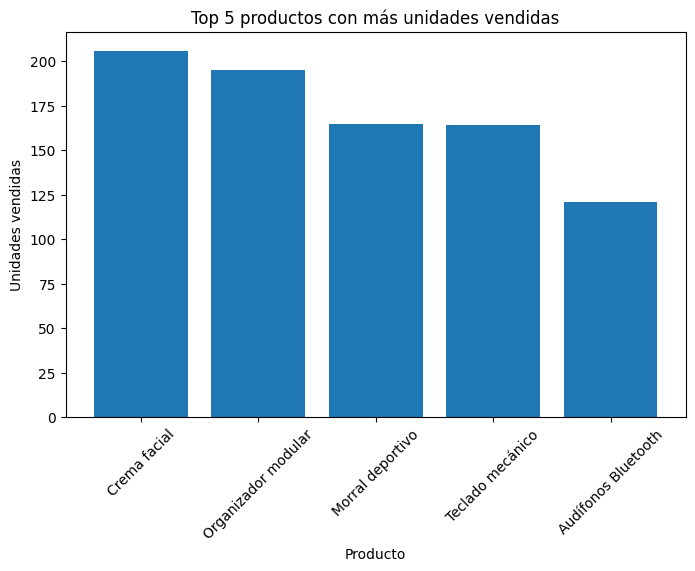

In [84]:
plt.figure(figsize=(8,5))

plt.bar(
    top_5_productos.index,
    top_5_productos.values
)

plt.title("Top 5 productos con más unidades vendidas")
plt.xlabel("Producto")
plt.ylabel("Unidades vendidas")
plt.xticks(rotation=45)

plt.show()

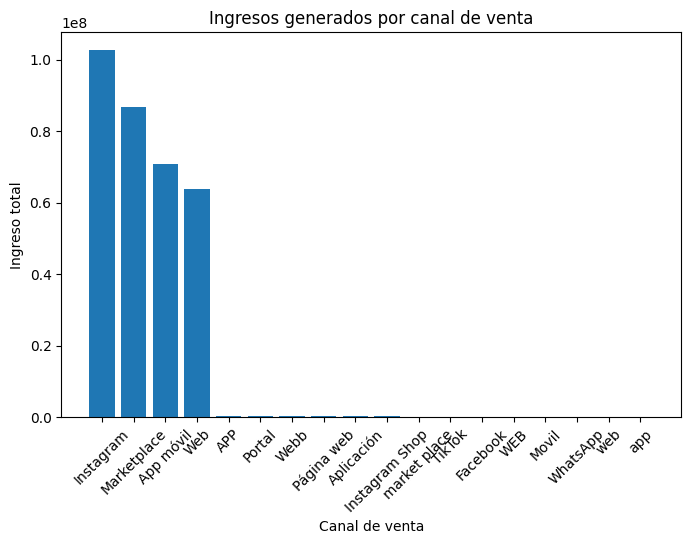

In [85]:
ingresos_por_canal = (
    df_clean.groupby("canal_venta")["total_pagado"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(
    ingresos_por_canal.index,
    ingresos_por_canal.values
)

plt.title("Ingresos generados por canal de venta")
plt.xlabel("Canal de venta")
plt.ylabel("Ingreso total")
plt.xticks(rotation=45)

plt.show()

In [87]:
gasto_por_segmento = (
    df_clean.groupby("segmento_cliente", as_index=False)["total_pagado"]
    .mean()
    .sort_values("total_pagado", ascending=False)
)

gasto_por_segmento

,segmento_cliente,total_pagado
1,Corp.,276000.000000
6,Nuevo,192882.516779
2,Corporativo,177394.193750
11,VIP,175145.450111
10,Recurrente,172430.680114
3,Empresa,132000.000000
0,Cliente nuevo,128600.000000
12,Vip,126600.000000
15,visitante,125000.000000
9,Recurente,115300.000000


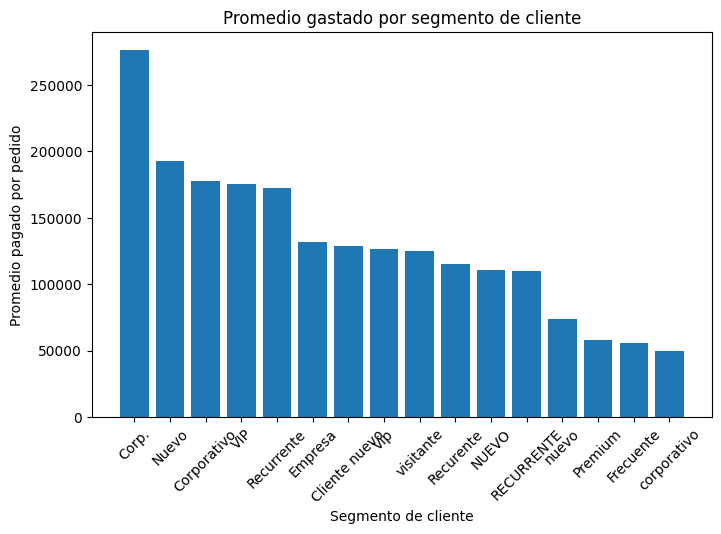

In [88]:
plt.figure(figsize=(8,5))

plt.bar(
    gasto_por_segmento["segmento_cliente"],
    gasto_por_segmento["total_pagado"]
)

plt.title("Promedio gastado por segmento de cliente")
plt.xlabel("Segmento de cliente")
plt.ylabel("Promedio pagado por pedido")
plt.xticks(rotation=45)

plt.show()